<a href="https://colab.research.google.com/github/th900/projeto-de-engenharia-de-dados-olist/blob/main/E_COMMERCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as  pd
import matplotlib.pyplot as plt
import os

In [41]:

## 01 - Carregando dados


base_url = "https://raw.githubusercontent.com/th900/projeto-de-engenharia-de-dados-olist/main/data_lake/raw/"
os.makedirs("data_lake/raw", exist_ok = True)

customers = pd.read_csv(base_url + "olist_customers_dataset.csv")
customers.to_csv("data_lake/raw/olist_customers_dataset.csv", index=False)

orders = pd.read_csv(base_url + "olist_orders_dataset.csv")
orders.to_csv("data_lake/raw/olist_orders_dataset.csv", index = False)

order_items = pd.read_csv(base_url +"olist_order_items_dataset.csv")
order_items.to_csv("data_lake/raw/olist_order_items_dataset.csv", index = False)

order_payments = pd.read_csv(base_url +"olist_order_payments_dataset.csv")
order_payments.to_csv("data_lake/raw/olist_order_payments_dataset.csv", index = False)

order_reviews = pd.read_csv(base_url +"olist_order_reviews_dataset.csv")
order_reviews.to_csv("data_lake/raw/olist_order_reviews_dataset.csv", index = False)

In [42]:
## 1.1 Analise do tamanho de cada dataframe

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", order_payments.shape)
print("Reviews:", order_reviews.shape)


Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)


In [43]:
## 1.2 Observando as primeiras linhas de cada dataframe

customers.head(5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [44]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [45]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [46]:
order_payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [47]:
order_reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [48]:
## 1.3 Obeservando os tipos das colunas

customers.info()
orders.info()
order_items.info()
order_payments.info()
order_reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [49]:
## 02 - Função para padronizar colunas do dataset

def padronizar_colunas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df


In [50]:
## 03 - Checando a qualidade dos dados

def data_profiling(df, nome_df):

    print(f"\n===== DATA PROFILING: {nome_df} =====\n")

    print("Shape do dataset:")
    print(df.shape)

    print("\nTipos de dados:")
    print(df.dtypes)

    print("\nValores nulos:")
    print(df.isnull().sum())

    print("\nDuplicatas:")
    print(df.duplicated().sum())

    print("\nCardinalidade (valores únicos por coluna):")
    print(df.nunique())


In [51]:
data_profiling(customers, "customers")


===== DATA PROFILING: customers =====

Shape do dataset:
(99441, 5)

Tipos de dados:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Valores nulos:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicatas:
0

Cardinalidade (valores únicos por coluna):
customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64


In [52]:
data_profiling(orders, "orders")


===== DATA PROFILING: orders =====

Shape do dataset:
(99441, 8)

Tipos de dados:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Valores nulos:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicatas:
0

Cardinalidade (valores únicos por coluna):
order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90

Há valores nulo pois nem todos os pedidos foram entregues ( há pedidos cancelados, por exemplo)


In [53]:
orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()


,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [54]:
data_profiling(order_items, "order_items")


===== DATA PROFILING: order_items =====

Shape do dataset:
(112650, 7)

Tipos de dados:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Valores nulos:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicatas:
0

Cardinalidade (valores únicos por coluna):
order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64


In [55]:
data_profiling(order_payments, "order_payments")


===== DATA PROFILING: order_payments =====

Shape do dataset:
(103886, 5)

Tipos de dados:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

Valores nulos:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Duplicatas:
0

Cardinalidade (valores únicos por coluna):
order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64


In [56]:
data_profiling(order_reviews, "order_reviews")


===== DATA PROFILING: order_reviews =====

Shape do dataset:
(99224, 7)

Tipos de dados:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

Valores nulos:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Duplicatas:
0

Cardinalidade (valores únicos por coluna):
review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64


In [57]:
### 3.1 Pedidos entregues antes de de serem comprados

orders[
    orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]
]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


Nenhum pedido pode ser entregue antes de ser comprado

In [58]:
### 3.2 Pedidos aprovados antes de serem comprados
orders[
    orders["order_approved_at"] < orders["order_purchase_timestamp"]
]



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


Nenhum pedido pode ser aprovado antes da compra

In [59]:
## 3.3 Verificação de preços

order_items[order_items["price"] < 0]


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


Preços acima de R$0,00

In [60]:
order_items[order_items["freight_value"] < 0]


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [61]:
## 04 Construção do DataLake




os.makedirs("data_lake/raw", exist_ok=True)
os.makedirs("data_lake/processed", exist_ok=True)
os.makedirs("data_lake/processed/customers", exist_ok=True)
os.makedirs("data_lake/processed/orders", exist_ok=True)
os.makedirs("data_lake/processed/order_items", exist_ok=True)
os.makedirs("data_lake/processed/order_payments", exist_ok=True)
os.makedirs("data_lake/processed/order_reviews", exist_ok=True)


Começaremos a criação de pipeline agora


In [62]:
## 05 - Pipeline ETL Completo


def extract(path):
    return pd.read_csv(path)


def load(df, path):
    df.to_parquet(path, index=False)



def transform_customers(df):
    df = df.drop_duplicates()
    df = df.dropna(subset=["customer_id", "customer_unique_id"])
    df["customer_zip_code_prefix"] = df["customer_zip_code_prefix"].astype(str)
    df = padronizar_colunas(df)
    return df


def transform_orders(df):
    df = df.drop_duplicates()
    df = df.dropna(subset=["order_id", "customer_id"])

    date_cols = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col])

    df = padronizar_colunas(df)
    return df


def transform_order_items(df):
    df = df.drop_duplicates()
    df = df.dropna(subset=["order_id", "product_id", "seller_id"])
    df["shipping_limit_date"] = pd.to_datetime(df["shipping_limit_date"])
    df = df[df["price"] > 0]
    df = df[df["freight_value"] >= 0]
    df = padronizar_colunas(df)
    return df


def transform_order_payments(df):
    df = df.drop_duplicates()
    df = df.dropna(subset=["order_id"])
    df = df[df["payment_value"] > 0]
    df = padronizar_colunas(df)
    return df


def transform_order_reviews(df):
    df = df.drop_duplicates()

    df = df.dropna(subset=["review_id", "order_id", "review_score"])
    df["review_creation_date"] = pd.to_datetime(df["review_creation_date"])
    df["review_answer_timestamp"] = pd.to_datetime(df["review_answer_timestamp"])
    df = padronizar_colunas(df)
    return df

In [63]:
## 5.1 - Executando o pipeline ETL

transforms = {
    "customers":      transform_customers,
    "orders":         transform_orders,
    "order_items":    transform_order_items,
    "order_payments": transform_order_payments,
    "order_reviews":  transform_order_reviews,
}

files = {
    "customers":      "olist_customers_dataset.csv",
    "orders":         "olist_orders_dataset.csv",
    "order_items":    "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews":  "olist_order_reviews_dataset.csv",
}

dfs_processed = {}

for name, file in files.items():
    raw_path = f"data_lake/raw/{file}"
    processed_path = f"data_lake/processed/{name}/{name}.parquet"

    os.makedirs(f"data_lake/processed/{name}", exist_ok=True)

    df = extract(raw_path)
    df_clean = transforms[name](df)
    load(df_clean, processed_path)

    dfs_processed[name] = df_clean
    print(f" {name}: {df_clean.shape[0]} linhas, {df_clean.shape[1]} colunas")

 customers: 99441 linhas, 5 colunas
 orders: 99441 linhas, 8 colunas
 order_items: 112650 linhas, 7 colunas
 order_payments: 103877 linhas, 5 colunas
 order_reviews: 99224 linhas, 7 colunas


In [64]:
## 5.2 - Camada curated

os.makedirs("data_lake/curated", exist_ok = True)


orders_delivered = dfs_processed["orders"] [dfs_processed["orders"]["order_status"]== 'delivered'].copy()

df_curated = orders_delivered.merge(
    dfs_processed["customers"],
    on = "customer_id",
    how = "left"
)

items_agg = dfs_processed["order_items"].groupby("order_id").agg(
    total_items = ("order_item_id", "count"),
    price = ("price", "sum"),
    freight_value = ("freight_value", "sum")
).reset_index()

df_curated = df_curated.merge(
    items_agg,
    on = "order_id",
    how = "left"
)

payments_agg = dfs_processed["order_payments"].groupby("order_id").agg(
    total_paid=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
    payment_type=("payment_type", "first")
).reset_index()

df_curated = df_curated.merge(payments_agg, on="order_id", how="left")


df_curated = df_curated.merge(
    dfs_processed["order_reviews"][["order_id", "review_score"]],
    on="order_id",
    how="left"
)


df_curated["delivery_days"] = (
    df_curated["order_delivered_customer_date"] - df_curated["order_purchase_timestamp"]
).dt.days


df_curated.to_parquet("data_lake/curated/olist_curated.parquet", index=False)

print(f" Curated: {df_curated.shape[0]} linhas, {df_curated.shape[1]} colunas")
print(df_curated.dtypes)

 Curated: 97007 linhas, 20 colunas
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                 object
customer_city                            object
customer_state                           object
total_items                               int64
price                                   float64
freight_value                           float64
total_paid                              float64
payment_installments                    float64
payment_type                             object
review_score                            float64
delivery_days                           float64
dtype

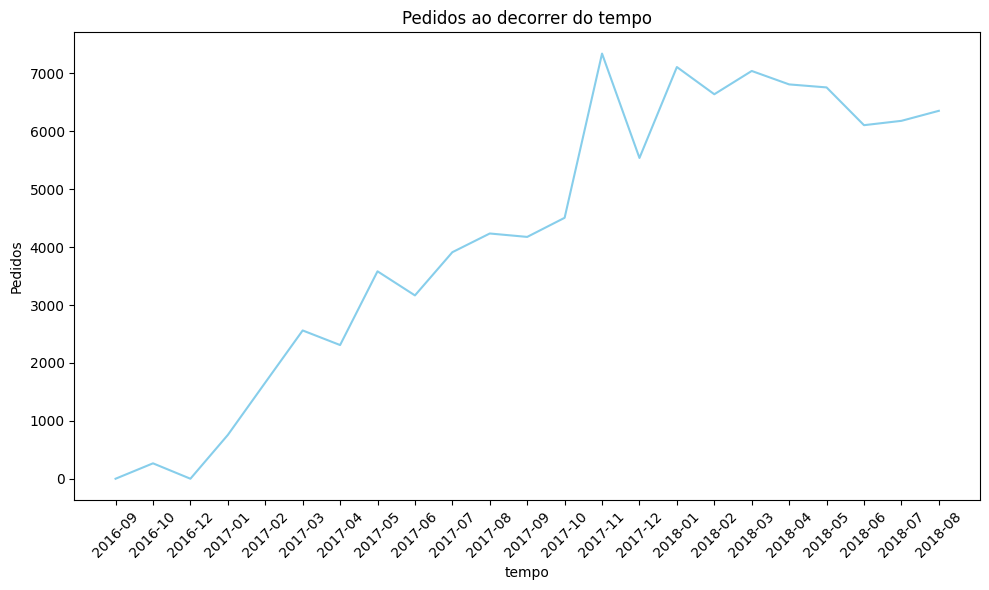

In [65]:
## 06 - Análise dos dados

plt.figure(figsize=(10, 6))
order_per_month = df_curated.groupby(df_curated["order_purchase_timestamp"].dt.to_period("M")).size()
plt.plot(order_per_month.index.astype(str), order_per_month.values, color = "Skyblue")
plt.title("Pedidos ao decorrer do tempo")
plt.xlabel("tempo")
plt.ylabel("Pedidos")
plt.xticks(rotation=45)
plt.tight_layout()

Text(65.72222222222221, 0.5, 'Pedidos')

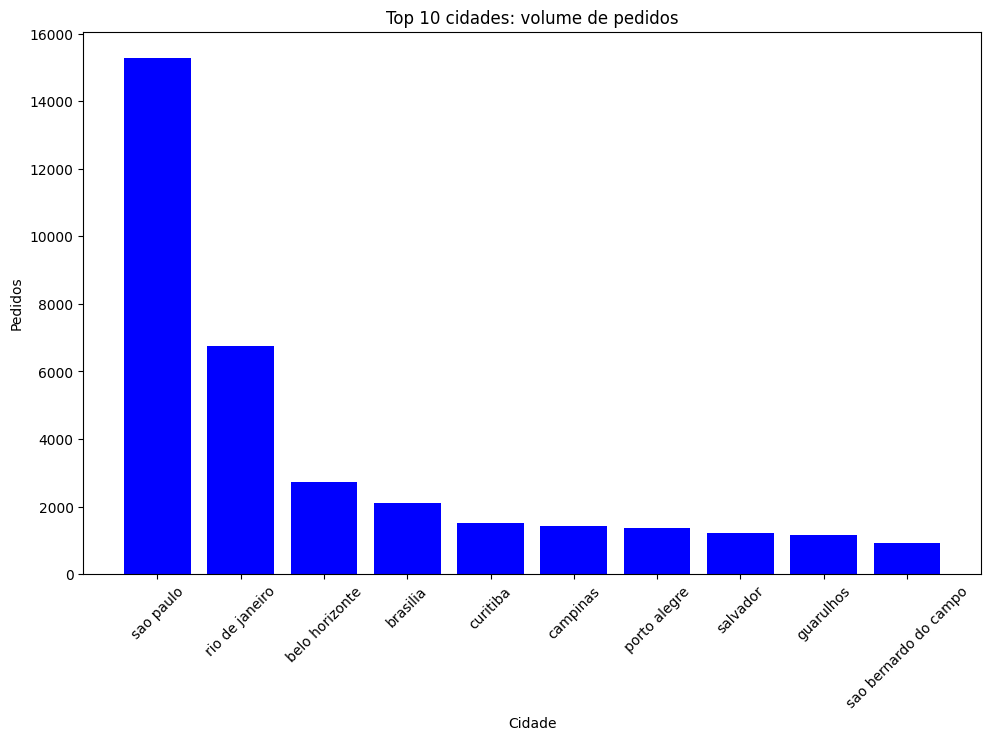

In [77]:
df_vol_score = dfs_processed["orders"].merge(dfs_processed["order_items"], on = "order_id").merge(dfs_processed["order_reviews"], on ="order_id").merge(dfs_processed["customers"], on = "customer_id" )

df_vol_score = df_vol_score.drop_duplicates(subset = "order_id")

df_vol_score = df_vol_score.groupby("customer_city").agg({
    "order_id": "count"}
).rename(columns={
    "order_id": "order_volume"
})

top10 = df_vol_score.sort_values("order_volume", ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10["order_volume"], color = "Blue")


plt.tight_layout()
plt.xticks(rotation = 45)
plt.title("Top 10 cidades: volume de pedidos")
plt.xlabel("Cidade")
plt.ylabel("Pedidos")

In [67]:
## 07 - Análise com SQL (DuckDB)

import duckdb


con = duckdb.connect()
con.register("curated", df_curated)


con.execute("SELECT COUNT(*) FROM curated").df()


,count_star()
0,97007


In [68]:
## 7.1 - Volume e satisfação por estado

query = """
SELECT
    customer_state,
    COUNT(order_id)              AS total_orders,
    ROUND(AVG(review_score), 2)  AS avg_review,
    ROUND(AVG(delivery_days), 1) AS avg_delivery_days
FROM curated
GROUP BY customer_state
ORDER BY total_orders DESC
"""

df_states_sql = con.execute(query).df()
df_states_sql.head(10)

,customer_state,total_orders,avg_review,avg_delivery_days
0,SP,40712,4.25,8.3
1,RJ,12420,3.96,14.9
2,MG,11423,4.19,11.5
3,RS,5382,4.19,14.8
4,PR,4942,4.24,11.5
5,SC,3560,4.13,14.5
6,BA,3273,3.93,18.9
7,DF,2099,4.13,12.5
8,ES,2004,4.08,15.3
9,GO,1974,4.10,15.1


In [69]:
## 7.2 - Impacto do tempo de entrega na satisfação

query = """
SELECT
    CASE
        WHEN delivery_days <= 7  THEN '1 - Até 7 dias'
        WHEN delivery_days <= 14 THEN '2 - 8 a 14 dias'
        WHEN delivery_days <= 30 THEN '3 - 15 a 30 dias'
        ELSE                          '4 - Mais de 30 dias'
    END AS delivery_category,
    COUNT(order_id)             AS total_orders,
    ROUND(AVG(review_score), 2) AS avg_review
FROM curated
WHERE delivery_days > 0
  AND delivery_days <= 60
GROUP BY delivery_category
ORDER BY delivery_category
"""

df_delivery_sql = con.execute(query).df()
df_delivery_sql

,delivery_category,total_orders,avg_review
0,1 - Até 7 dias,33827,4.41
1,2 - 8 a 14 dias,36602,4.29
2,3 - 15 a 30 dias,22416,3.91
3,4 - Mais de 30 dias,3852,2.18


In [70]:
## 7.3 - Estados acima da média nacional de satisfação

query = """
SELECT
    customer_state,
    ROUND(AVG(review_score), 2) AS avg_review,
    COUNT(order_id)             AS total_orders
FROM curated
GROUP BY customer_state
HAVING AVG(review_score) > (
    SELECT AVG(review_score) FROM curated
)
ORDER BY avg_review DESC
"""

df_above_avg = con.execute(query).df()
df_above_avg

,customer_state,avg_review,total_orders
0,SP,4.25,40712
1,PR,4.24,4942
2,AP,4.24,67
3,AM,4.22,146
4,RS,4.19,5382
5,MG,4.19,11423
6,RO,4.17,243
7,MS,4.17,712


In [71]:
## 7.4 - Total de pedidos e ticket médio por forma de pagamento

query = """

  SELECT
    COUNT(order_id) as total_orders,
    payment_type,
    ROUND(AVG(total_paid),2) as avg_total_paid
  from curated
  GROUP BY payment_type
  ORDER BY total_orders desc
"""

df_payment_type = con.execute(query).df()
df_payment_type

,total_orders,payment_type,avg_total_paid
0,73605,credit_card,165.37
1,19308,boleto,144.31
2,2602,voucher,124.70
3,1491,debit_card,140.24
4,1,None,NaN


In [72]:
## 7.5 - Meses em que houve a maior quantidade de vendas

query = """
  SELECT
    COUNT(order_id) as total_orders,
    STRFTIME('%Y-%m', order_approved_at) as mes
  FROM curated
  GROUP BY mes
  ORDER BY total_orders desc
"""

df_month = con.execute(query).df()
df_month.head(5)

,total_orders,mes
0,7202,2017-11
1,7122,2018-03
2,7029,2018-01
3,6948,2018-05
4,6650,2018-04


In [73]:
## 7.6 - Dias até a aprovação do pedido

con.register("orders_raw", dfs_processed["orders"])
con.register("payments_raw", dfs_processed["order_payments"])

query = """
SELECT
    p.payment_type,
    COUNT(o.order_id) as total_orders,
    ROUND(AVG( DATEDIFF('day', o.order_purchase_timestamp, o.order_approved_at) ), 1) as avg_days_to_approve
FROM orders_raw o
JOIN payments_raw p
    ON o.order_id = p.order_id
WHERE o.order_approved_at IS NOT NULL
GROUP BY p.payment_type
ORDER BY avg_days_to_approve
"""

df_approval = con.execute(query).df()
df_approval

,payment_type,total_orders,avg_days_to_approve
0,credit_card,76739,0.2
1,debit_card,1529,0.4
2,voucher,5683,0.4
3,boleto,19754,1.8
